In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../")

#spectrome modules
from spectrome.utils import functions, path
from spectrome.brain import Brain


from spectrome.forward import ntf_local_stimulus as nt_stim
from spectrome.forward import ntf_local as nt_nostim
from spectrome.forward import ntf_local_stimulus as nt_stim

from scipy.io import loadmat
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import fdrcorrection

from scipy.io import savemat
import pickle as pkl

In [2]:
# All regions
df=pd.read_excel('../../ListROIs_DK.xlsx')
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    all_regions_idx.append(i)
    all_regions.append(r['ROI'].strip("'"))

all_regions=[r.replace(' L', '-lh').replace(' R', '-rh') for r in all_regions[:68]]

In [3]:
all_r_values = [-0.02112489, -0.00515559,  0.01320459, -0.0568756 , -0.04951881,
       -0.05998161, -0.11213403, -0.05638488,  0.01165748, -0.12131528,
        0.0042193 ,  0.00413313, -0.00445442, -0.03523392,  0.02911025,
       -0.0520392 ,  0.02616619, -0.05857385, -0.02012454, -0.11862786,
       -0.01782576,  0.00756556, -0.03397264, -0.00739839,  0.04833741,
        0.04198397, -0.02803163, -0.02077155,  0.011663  , -0.07446908,
       -0.1205172 , -0.05805189,  0.0905253 , -0.0556201 , -0.07596635,
       -0.0221981 , -0.03779691, -0.10623783,  0.10573129, -0.00933071,
        0.01774047,  0.0137667 ,  0.03301989, -0.01381388, -0.10709519,
       -0.02346254, -0.03047375,  0.03275727, -0.09331918,  0.38251603,
       -0.02118546, -0.0663981 ,  0.01199736, -0.02179558, -0.05046284,
       -0.14407384, -0.04866554, -0.03082643, -0.20056716, -0.06788891,
       -0.05640032, -0.01455137, -0.04831198, -0.00740195,  0.10280894,
       -0.05031179, -0.04868212, -0.07907368]

df_gei = pd.DataFrame(all_r_values, index=all_regions, columns=['r'])

### Brain Plots

In [4]:
'''
Code: To plot various brain region from DK atlas
'''
import xarray as xr
import mne
import matplotlib.pyplot as plt
from mne.viz import plot_brain_colorbar
from mne.viz import Brain
from mne.datasets import fetch_fsaverage
import os.path as op
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from matplotlib import colormaps as cmaps
import numpy as np

# pip install netCDF4 h5netcdf
# !pip install pyvistaqt ipywidgets

In [5]:
data_xr = xr.open_dataarray("individual_psd_reordered_matlab.nc")
psd = data_xr.values
regions = data_xr["regionx"].values

In [6]:
regions_mne = []
count = 0

for i in range(len(regions)):
    if regions[i][0:2] == 'LH':
        regionname = regions[i][2:]
        regions_mne.append(regionname + '-lh')

    if regions[i][0:2] == 'RH':
        regionname = regions[i][2:]
        regions_mne.append(regionname + '-rh')


In [7]:
# Fetch fsaverage dataset
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)

# Load fsaverage subject details
subject = "fsaverage"
trans = "fsaverage"  # Built-in fsaverage transformation in MNE
src_fname = op.join(fs_dir, "bem", "fsaverage-ico-5-src.fif")

# Read source spaces
src = mne.read_source_spaces(src_fname)

# Load labels from the fsaverage atlas
labels = mne.read_labels_from_annot(subject, parc="aparc", subjects_dir=subjects_dir)

0 files missing from root.txt in /Users/apurbadebnath/mne_data/MNE-fsaverage-data
0 files missing from bem.txt in /Users/apurbadebnath/mne_data/MNE-fsaverage-data/fsaverage
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Reading labels from parcellation...
   read 35 labels from /Users/apurbadebnath/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/apurbadebnath/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot


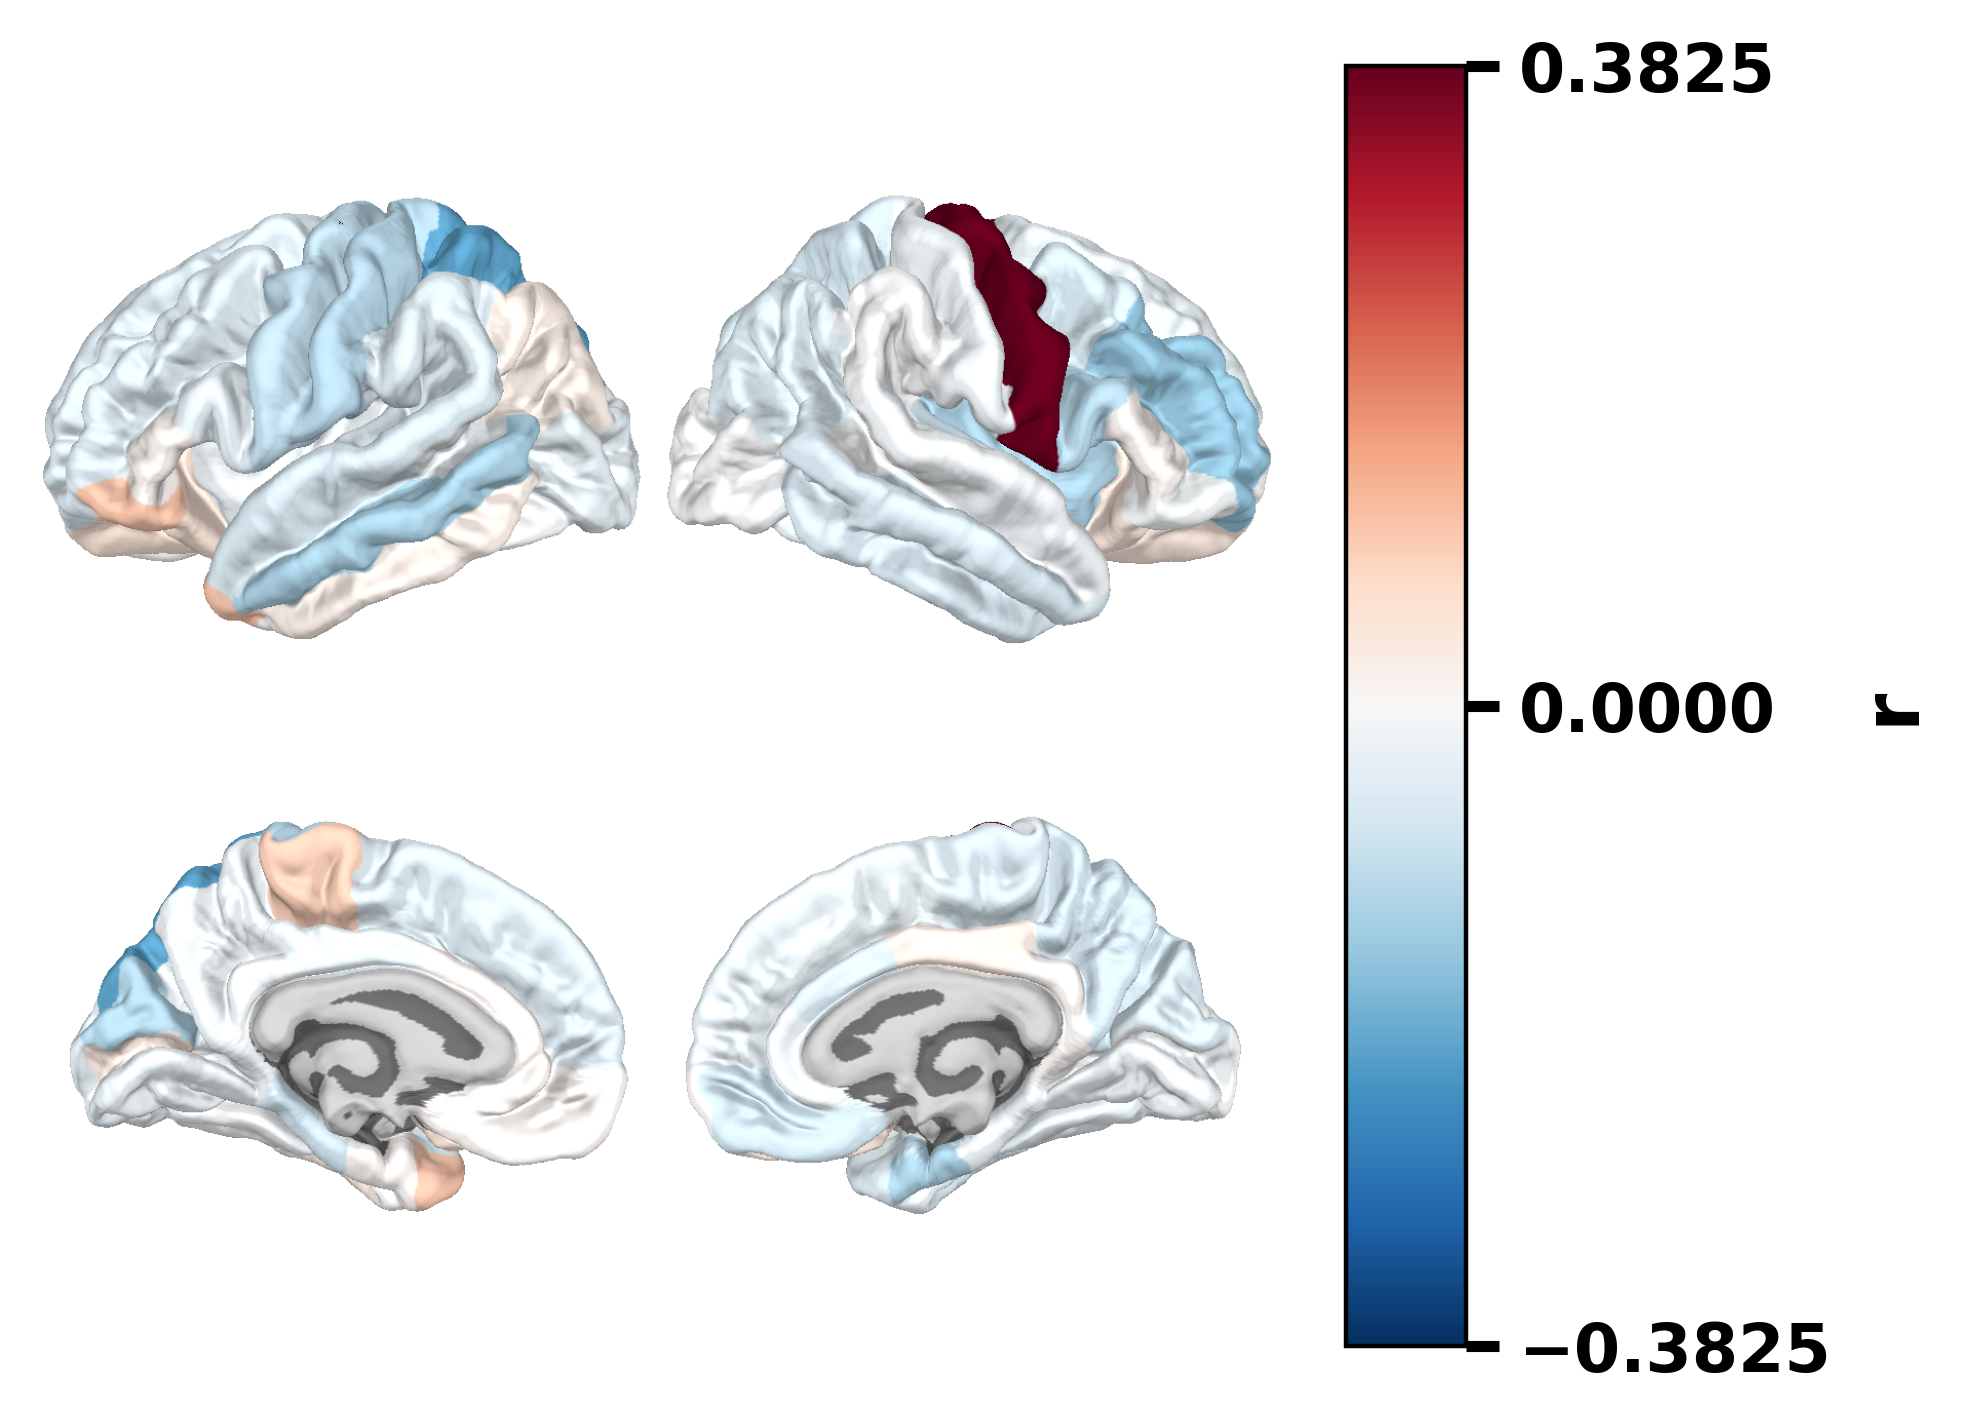

In [10]:
max_val = df_gei["r"].max()
min_val = df_gei["r"].min()

# max_val = df_gei[['S3']].to_numpy().max()
# min_val = df_gei[['S3']].to_numpy().min()

##For plotting mean(MI/RS-1)
roi_tvalues = dict(zip(list(df_gei.index), list(df_gei['r'])))

brain = Brain(
    subject=subject,
    subjects_dir=subjects_dir,
    surf="pial",
    hemi="split",  
    background="white",
    views=["lat", "med"],
    # views=["dorsal"],
    size=(600, 600),
    # offset='auto',
    # view_layout='horizontal',
    # show=False, 
)

cmap = cmaps.get_cmap("RdBu_r") #changing RdBu_r to RdBu to make reddish appearance for greater values
# vmin, vmax = -np.max(list(df_gei['S3'])), np.max(list(df_gei['S3']))  
vmin, vmax = -max_val, max_val # Use the max value from all sessions
norm = Normalize(vmin=vmin, vmax=vmax)


for label in labels:
    if label.name in all_regions:  
        t_value = roi_tvalues[label.name]
        rgba_color = cmap(norm(t_value))
        brain.add_label(label, color=rgba_color[:4]) 



clim = dict(kind="value", lims=[vmin, (vmin+vmax)/2, vmax])
brain.save_image("pfdr_taue_meg_sess1.png")
#the combined plot
fig, ax = plt.subplots(figsize=(6, 4), dpi=400) 

brain_image = plt.imread("pfdr_taue_meg_sess1.png")
ax.imshow(brain_image)
ax.axis('off')  

#vertical colorbar next to the brain image
cbar_ax = fig.add_axes([0.8, 0.1, 0.05, 0.8]) 
# [0.15, 0.1, 0.7, 0.3]-->becomes horizontal
# [0.8, 0.1, 0.05, 0.8]--vertical
cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax)

# Set colorbar label with larger font
cb.set_label("r", fontsize=14, weight='bold')

# Set custom ticks and formatting
cb.set_ticks([vmin, (vmin + vmax) / 2, vmax])
cb.ax.tick_params(
    axis='y',
    which='both',
    length=6,       
    width=2,       
    colors='black', 
    # direction='out',
    labelsize=12    
)

# bolden each tick label
for label in cb.ax.get_yticklabels():
    label.set_fontweight('bold')


# plt.savefig(f"/Users/apurbadebnath/Desktop/brain_plot_repeated_measure_r.png", dpi=400)
plt.show()
